In [1]:
from langgraph.graph import StateGraph, START, END

from typing_extensions import TypedDict, NotRequired

from spm_agent.states.image_analysis_state import Channel, SegmentationResult

from spm_agent.nodes.readfile_node import readfile_node
from spm_agent.nodes.channel_recommendation_node import channel_recommendation_node
from spm_agent.nodes.agentic_segmentation_node import agentic_segmentation_node

In [2]:
EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    "Study wall-mediated switching"
]

In [3]:
class ImportanceMapResult(TypedDict):
    experiment_task: str            # free-form goal — lives HERE, per your point
    importance_map_path: str        # .npy, pixel grid
    scoring_code_path: str
    reasoning: str

class ImageAnalysisState(TypedDict):
    file_path: str
    file_channels: NotRequired[dict[str, Channel]]
    channel_recommendations: NotRequired[dict]
    segmentation_results: NotRequired[dict[str, SegmentationResult]]
    experiment_tasks: NotRequired[list[ImportanceMapResult]] 
    importance_maps: NotRequired[list[ImportanceMapResult]] 

In [4]:
def make_experiment_tasks_node(experiment_tasks:list[str]):
    async def set_experiment_tasks_node(state: ImageAnalysisState) -> ImageAnalysisState:
        return {"experiment_tasks": experiment_tasks} # type: ignore
    return set_experiment_tasks_node

In [7]:
from spm_agent.config import IMPORTANCE_DIR
from spm_agent.tools.run_python import make_run_python, LocalBackend, extract_run_python_code
from spm_agent.utils.message_utils import flatten_text
from spm_agent.config import SANDBOX_PY, SEG_MODEL, SEG_MAX_TOKENS, SEG_MAX_SUPERSTEPS
from spm_agent.prompts.importance_map_prompts import build_importance_human_message, build_importance_system_message

from langchain_anthropic import ChatAnthropic
from langchain.agents import create_agent

from pathlib import Path
import shutil

def _make_workdir() -> Path:
    wd = IMPORTANCE_DIR / "work"
    if wd.exists():
        shutil.rmtree(wd)
    wd.mkdir(parents=True, exist_ok=True)
    return wd

async def importance_map_node(state: ImageAnalysisState) -> ImageAnalysisState:
    tasks    = state.get("experiment_tasks", [])
    channels = state["file_channels"]           # type: ignore
    seg      = state["segmentation_results"]     # type: ignore

    wd = _make_workdir()
    run_python = make_run_python(LocalBackend(wd, SANDBOX_PY, timeout=30))
    model = ChatAnthropic(model=SEG_MODEL, temperature=0, max_tokens=SEG_MAX_TOKENS)  # type: ignore
    IMPORTANCE_DIR.mkdir(parents=True, exist_ok=True)

    importance_maps = []
    for i, task in enumerate(tasks):
        agent = create_agent(model, tools=[run_python],
                             system_prompt=build_importance_system_message())

        out = await agent.ainvoke(
            {"messages": [build_importance_human_message(task, channels, seg)]},
            config={"recursion_limit": SEG_MAX_SUPERSTEPS*2},
        )

        src       = wd / "importance_map.npy"
        map_path  = IMPORTANCE_DIR / f"importance_map_{i}.npy"
        code_path = IMPORTANCE_DIR / f"scoring_code_{i}.py"
        if src.exists():
            shutil.copy(src, map_path)
            src.unlink()
        code_path.write_text(extract_run_python_code(out["messages"]))

        importance_maps.append({
            "experiment_task": task,
            "importance_map_path": str(map_path),
            "scoring_code_path": str(code_path),
            "reasoning": flatten_text(out["messages"][-1].content),
            "candidate_regions": [],           # filled later by the deterministic pick node
        })

    
    return {"importance_maps": importance_maps}   # type: ignore   

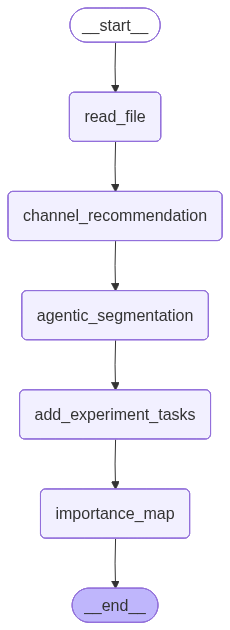

In [8]:
builder = StateGraph(ImageAnalysisState)
builder.add_node("read_file", readfile_node)
builder.add_node("channel_recommendation", channel_recommendation_node)
builder.add_node("agentic_segmentation", agentic_segmentation_node)
builder.add_node("add_experiment_tasks", make_experiment_tasks_node(EXPERIMENT_TASKS)) # type: ignore
builder.add_node("importance_map", importance_map_node)

builder.add_edge(START, "read_file")
builder.add_edge("read_file", "channel_recommendation")
builder.add_edge("channel_recommendation", "agentic_segmentation")
builder.add_edge("agentic_segmentation", "add_experiment_tasks")
builder.add_edge("add_experiment_tasks", "importance_map")
builder.add_edge("importance_map", END)

im_graph = builder.compile()
im_graph

In [9]:
result = await im_graph.ainvoke(
    {
        "file_path": r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw",
    }
)

In [ ]:
result
        




{'file_path': '/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw',
 'file_channels': {'Channel_000': {'title': 'HeightRetrace',
   'units': 'm',
   'data_type': 'IMAGE',
   'shape': [256, 256],
   'stats': {'min': -4.108699158678064e-09,
    'max': 6.594916612812085e-09,
    'mean': -8.413408858487514e-17,
    'std': 1.868449575889247e-09,
    'p01': -2.8537556318042336e-09,
    'p99': 4.834470246350975e-09},
   'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.png',
   'array_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.npy'},
  'Channel_001': {'title': 'Amplitude1Retrace',
   'units': 'm',
   'data_type': 'IMAGE',
   'shape': [256, 256],
   'stats': {'min': 9.537324922870294e-12,
    'max': 1.3852193003760505e-10,
    'mean': 4.359126417787222e-11,
    'std': 2.42064727515004e-11,
    'p01': 1.2897779328932546e-11,
    'p99': 1.043379979637

In [11]:
# --- Cell: importance-map visualization helpers ---
import numpy as np
import matplotlib.pyplot as plt


def _view01(a, p=(1, 99)):
    """Robust [0,1] view of a channel for use as a grayscale backdrop."""
    a = a.astype(float); f = a[np.isfinite(a)]
    lo, hi = np.percentile(f, p) if f.size else (0.0, 1.0)
    return np.clip((a - lo) / (hi - lo + 1e-12), 0, 1)


def show_importance_map(result, ax=None):
    """Bare heatmap of one importance map, titled by its experiment task."""
    m = np.load(result["importance_map_path"])
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(m, cmap="inferno", vmin=0, vmax=100)
    ax.set_title(result["experiment_task"], fontsize=9)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")
    return ax


def compare_importance_maps(results):
    """All maps side by side — quick way to see they differ per task."""
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    axes = np.atleast_1d(axes)
    for ax, r in zip(axes, results):
        show_importance_map(r, ax=ax)
    plt.tight_layout(); plt.show()


def show_importance_over_channel(result, channel_array_path, mask_paths=None, alpha=0.55):
    """Channel grayscale + importance heatmap overlaid, with optional mask contours."""
    ch = _view01(np.load(channel_array_path))
    m  = np.load(result["importance_map_path"])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(ch, cmap="gray")
    im = ax.imshow(np.ma.masked_less(m, 1), cmap="inferno", vmin=0, vmax=100, alpha=alpha)
    for mp in (mask_paths or []):
        ax.contour(np.load(mp).astype(float), levels=[0.5], colors="cyan", linewidths=0.6)
    ax.set_title(result["experiment_task"], fontsize=9); ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")
    plt.show()


def region_importance(result, mask_paths: dict):
    """Mean importance per named region, e.g. {'domain': path, 'wall': path}. + background."""
    m = np.load(result["importance_map_path"])
    masks = {k: np.load(v).astype(bool) for k, v in mask_paths.items()}
    out = {k: (round(float(m[mk].mean()), 1) if mk.any() else None) for k, mk in masks.items()}
    bg = ~np.logical_or.reduce(list(masks.values())) if masks else np.ones_like(m, bool)
    out["background"] = round(float(m[bg].mean()), 1)
    return out


def show_top_peaks(result, channel_array_path, k=5, min_sep=15):
    """Preview of the deferred deterministic pick: greedy top-k peaks with a pixel min-separation."""
    m = np.load(result["importance_map_path"]); mm = m.copy()
    H, W = m.shape; yy, xx = np.ogrid[:H, :W]; pts = []
    for _ in range(k):
        r, c = np.unravel_index(np.argmax(mm), mm.shape)
        pts.append((int(r), int(c)))
        mm[(yy - r) ** 2 + (xx - c) ** 2 <= min_sep ** 2] = -1
    ch = _view01(np.load(channel_array_path))
    fig, ax = plt.subplots(figsize=(6, 6)); ax.imshow(ch, cmap="gray")
    ax.imshow(np.ma.masked_less(m, 1), cmap="inferno", vmin=0, vmax=100, alpha=0.5)
    for i, (r, c) in enumerate(pts):
        ax.plot(c, r, "o", mfc="none", mec="cyan", ms=14, mew=2)
        ax.text(c + 4, r, str(i + 1), color="cyan", fontsize=9)
    ax.set_title(f"{result['experiment_task']} — top {k}", fontsize=9); ax.axis("off"); plt.show()
    return pts

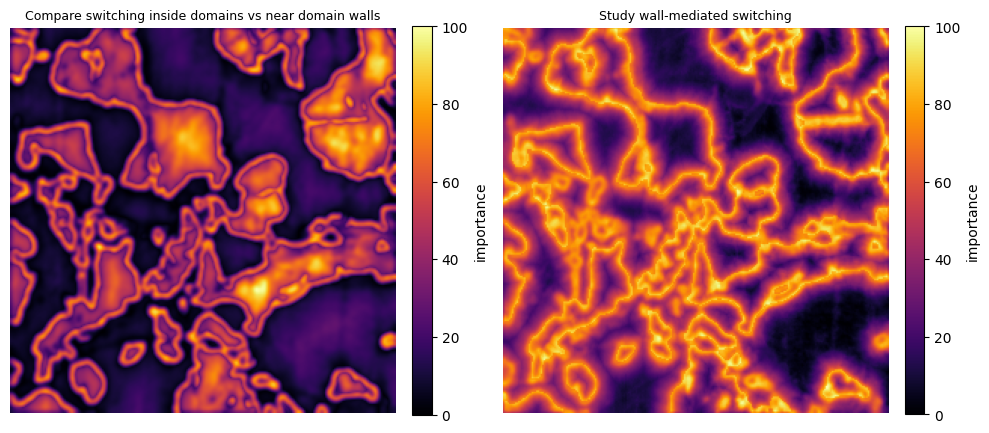

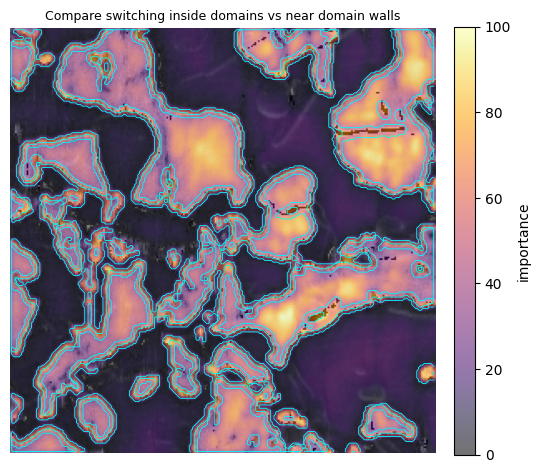

map_0 by region: {'domain': 50.5, 'wall': 51.3, 'background': 12.4}
map_1 by region: {'domain': 59.2, 'wall': 74.7, 'background': 32.9}


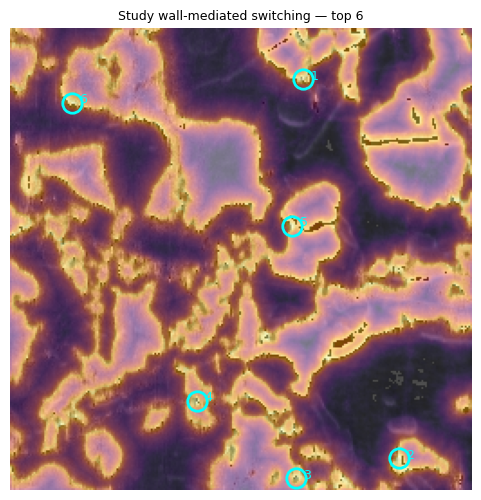

[(28, 162), (238, 215), (249, 158), (206, 103), (109, 156), (41, 34)]

In [14]:
# --- Cell: usage (paths from state, cwd-independent) ---
maps     = result["importance_maps"]
channels = result["file_channels"]
seg      = result["segmentation_results"]

phase = channels["Channel_003"]["array_path"]                       # absolute
dom   = seg["ferroelectric domain segmentation"]["mask_path"]       # absolute
wall  = seg["ferroelectric domain wall segmentation"]["mask_path"]  # absolute

compare_importance_maps(maps)
show_importance_over_channel(maps[0], phase, mask_paths=[dom, wall])
print("map_0 by region:", region_importance(maps[0], {"domain": dom, "wall": wall}))
print("map_1 by region:", region_importance(maps[1], {"domain": dom, "wall": wall}))
show_top_peaks(maps[1], phase, k=6, min_sep=15)

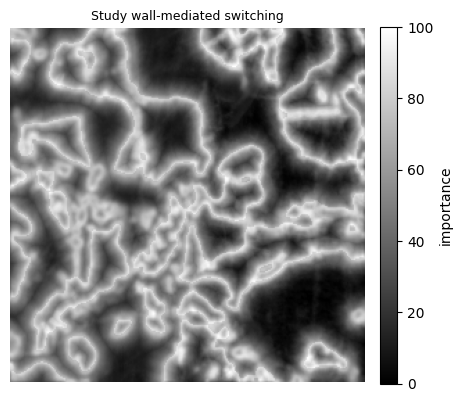

In [42]:
m = np.load(result['importance_maps'][1]['importance_map_path'])

_, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(m, cmap="gray", vmin=0, vmax=100)
ax.set_title(result['importance_maps'][1]['experiment_task'], fontsize=9)
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="importance")

In [39]:
from IPython.display import display, Markdown

def show_reasoning(result):
    display(Markdown(f"### {result['experiment_task']}\n\n{result['reasoning']}"))

for r in maps:
    show_reasoning(r)

### Compare switching inside domains vs near domain walls

The importance map looks excellent. Both domain interiors and domain walls receive balanced high scores (~50 each), while regions outside both masks score low (~12). The map clearly highlights both types of locations needed for the comparison experiment.

---

**Criteria chosen and rationale:**

**Domain interior score** (applied within the domain mask): weighted combination of (1) **PFM amplitude** (Amp1+Amp2 average, 40%) — high amplitude ensures a reliable, measurable switching response; (2) **distance from domain wall** (30%) — pixels deep inside a domain are the most representative of bulk switching behavior, free from wall-proximity effects; (3) **phase uniformity** (inverse gradient, 20%) — stable, uniform phase confirms a well-defined polarization state ideal for baseline switching measurements; (4) **local frequency variation** (10%) — captures subtle stiffness heterogeneity that may modulate switching.

**Domain wall score** (applied within the wall mask): weighted combination of (1) **phase gradient magnitude** (35%) — strong phase transitions mark the sharpest, most physically meaningful wall positions; (2) **wall-band centrality** (distance transform inside wall mask, 35%) — pixels at the center of the wall band are the most unambiguous wall locations; (3) **amplitude dip** (inverse amplitude, 20%) — the characteristic amplitude minimum at domain walls confirms genuine wall character; (4) **local frequency variation** (10%) — wall regions with stiffness contrast are most informative for switching comparison.

The final map takes the **maximum** of both smoothed scores, ensuring both domain interiors and domain walls are equally prioritized for local measurements, while suppressing unclassified background regions — directly serving the goal of comparing switching behavior between the two structural environments.

### Study wall-mediated switching

The `importance_map.npy` is saved and validated. Here is the reasoning:

---

**Scoring criteria for wall-mediated switching:**

Six complementary criteria were combined into a weighted importance score:

1. **Wall proximity (30%)** — A Gaussian-decay distance transform from the segmented domain wall mask (σ = 6 px) ensures that pixels on or immediately adjacent to walls receive the highest base score, since wall-mediated switching is by definition initiated at and propagated along domain walls.

2. **Phase1 gradient magnitude (20%)** — The spatial gradient of the first-harmonic PFM phase identifies sharp polarization contrast boundaries. High-gradient loci mark well-defined, mechanically active wall segments where switching fronts are most likely to nucleate and propagate.

3. **Phase2 gradient magnitude (15%)** — The second-harmonic phase gradient provides an independent confirmation of wall sharpness and non-linear electromechanical response, both of which are enhanced at switching-competent walls.

4. **Amplitude suppression (15%)** — Low PFM amplitude (both harmonics averaged) at wall regions reflects the depolarization zone characteristic of domain walls; these sites are most susceptible to tip-field-driven switching.

5. **Phase1 local variance (10%)** — Regions with high local polarization heterogeneity (computed over a 9-pixel window) indicate metastable or mixed-phase areas where the energy barrier for switching is reduced, making them secondary nucleation candidates.

6. **Domain–wall interface bonus (10%)** — Pixels that lie within the ferroelectric domain mask AND are within ~4 px of a wall boundary represent the exact nucleation front geometry for wall-mediated switching, receiving an additional boost.

In [33]:
# harvest THIS task's map before the next task can overwrite it in the shared dir
src       = _wd / "importance_map.npy"
map_path  = IMPORTANCE_DIR / f"importance_map_1.npy"
code_path = IMPORTANCE_DIR / f"scoring_code_1.py"
if src.exists():
    shutil.copy(src, map_path)
src.unlink()
code_path.write_text(_extract_code(out["messages"]))

24082

In [34]:
print(out.keys())                # dict_keys(['messages', ...])
print(type(out["messages"][-1])) # AIMessage
print(out["messages"][-1].content)

dict_keys(['messages'])
<class 'langchain_core.messages.ai.AIMessage'>
The `importance_map.npy` is saved and validated (256×256, float64, all finite, range 0–100).

---

## Criteria and Rationale

The importance map was built with a **two-branch scoring strategy** designed to identify the best pixels for local switching spectroscopy (e.g., SS-PFM) in both contexts needed for the comparison:

**Branch A — Domain interior quality** (pixels inside domain mask, away from walls):
- **PFM amplitude quality** (avg. of Amplitude1 & Amplitude2, normalised): high amplitude means a strong piezoelectric signal and a reliable, high-SNR switching hysteresis loop.
- **Local phase uniformity** (1 − local std of Phase2 in a 7×7 window): low phase variance confirms the pixel sits well inside a single polarisation state, giving a clean, unambiguous switching reference.
- **Distance from domain wall** (EDT of wall mask): rewards pixels deep in the domain interior, far from any wall-induced depolarisation 